In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from koreanize_matplotlib import koreanize
koreanize()

In [4]:
df = pd.read_csv('../data/realistic_sales_data.csv')

In [7]:
df.head()

,date,sales
0,2020-01-01,114.0
1,2020-01-02,100.0
2,2020-01-03,121.0
3,2020-01-04,201.0
4,2020-01-05,154.0


### - 타임시리즈 데이터 분석에 prophet 을 이용해 보자

In [68]:
# prophet 설치해주기
! pip install prophet

In [10]:
from prophet import Prophet

### - 매출 시각화 하기

In [13]:
df.head()

,date,sales
0,2020-01-01,114.0
1,2020-01-02,100.0
2,2020-01-03,121.0
3,2020-01-04,201.0
4,2020-01-05,154.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1827 non-null   object 
 1   sales   1827 non-null   float64
dtypes: float64(1), object(1)
memory usage: 28.7+ KB


In [19]:
# 컬럼을 날짜로 바꿔주기 
# => parse_dates = [] : 변경해줄 날짜 컬럼을 리스트로 묶어주면 된다
df = pd.read_csv('../data/realistic_sales_data.csv', parse_dates = ['date'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1827 non-null   datetime64[ns]
 1   sales   1827 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 28.7 KB


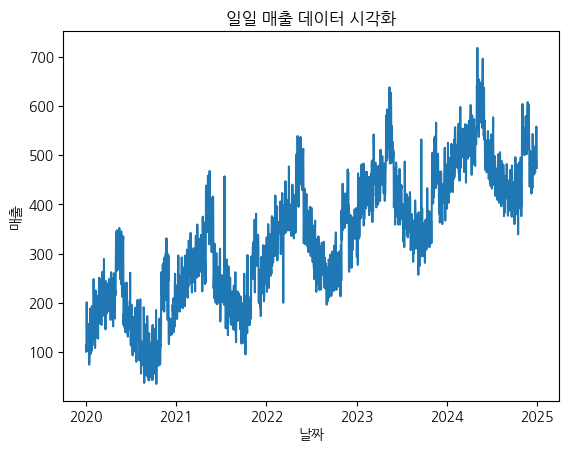

In [22]:
plt.plot(df['date'], df['sales'], label = '일일 매출')
plt.title('일일 매출 데이터 시각화')
plt.xlabel('날짜')
plt.ylabel('매출')
plt.show()

In [23]:
model = Prophet()

### - prophet 라이브러리의 fit 함수에는 데이터 프레임을 넣되, 필수인 컬럼이 있어야 한다    
- 날짜 컬럼은 ds    
- 예측 하고 싶은 y 가 있어야 한다   

In [25]:
# 필수값 미입력시 오류남
model.fit(df)

TypeError: Prophet.fit() missing 1 required positional argument: 'df'

#### * date와 sales를 ds, y로 바꿔주기

In [42]:
df.head()

,ds,y
0,2020-01-01,114.0
1,2020-01-02,100.0
2,2020-01-03,121.0
3,2020-01-04,201.0
4,2020-01-05,154.0


In [27]:
# 1번째 방법
df.rename(columns= {'date' : 'ds', 'sales' : 'y'})

,ds,y
0,2020-01-01,114.0
1,2020-01-02,100.0
2,2020-01-03,121.0
3,2020-01-04,201.0
4,2020-01-05,154.0
...,...,...
1822,2024-12-27,489.0
1823,2024-12-28,534.0
1824,2024-12-29,558.0
1825,2024-12-30,510.0


In [29]:
# 2번째 방법
df.columns = ['ds','y']

In [31]:
df.head()

,ds,y
0,2020-01-01,114.0
1,2020-01-02,100.0
2,2020-01-03,121.0
3,2020-01-04,201.0
4,2020-01-05,154.0


In [32]:
# df의 date, sales => ds, y로 바꿔준 후 df다시 입력하면 실행 됨
model.fit(df)

10:06:10 - cmdstanpy - INFO - Chain [1] start processing
10:06:11 - cmdstanpy - INFO - Chain [1] done processing


#### - 미래 데이터를 저장할 데이터프레임을 생성  
 - make_future_dataframe(periods = 365, freq = 'D')
 - => periods = 미래로 생성할 날짜 행의 개수
 - => freq = 날짜의 주기, D =날짜 or W = 주, M = 월, Y = 연도 

In [43]:
# 빈 껍데기
future = model.make_future_dataframe( periods = 365, freq = 'D' )

#### => 실제로 예측하기

In [44]:
# 껍데기에 데이터 예측해서 넣어주기
forecast = model.predict(future)

#### => prophet 라이브러리는 예측 결과를 시각화 함수로 제공한다  
- 차트의 검은 점 = 실제 데이터
- 2025년 이후는 예측 데이터

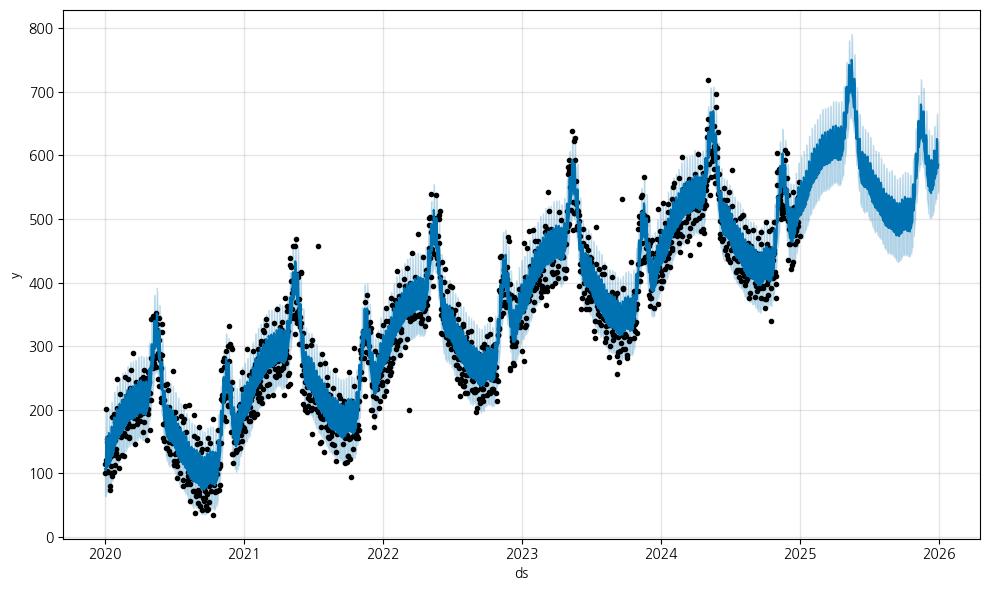

In [45]:
model.plot(forecast)
plt.show()

### => 트렌드 및 계절성 시각화

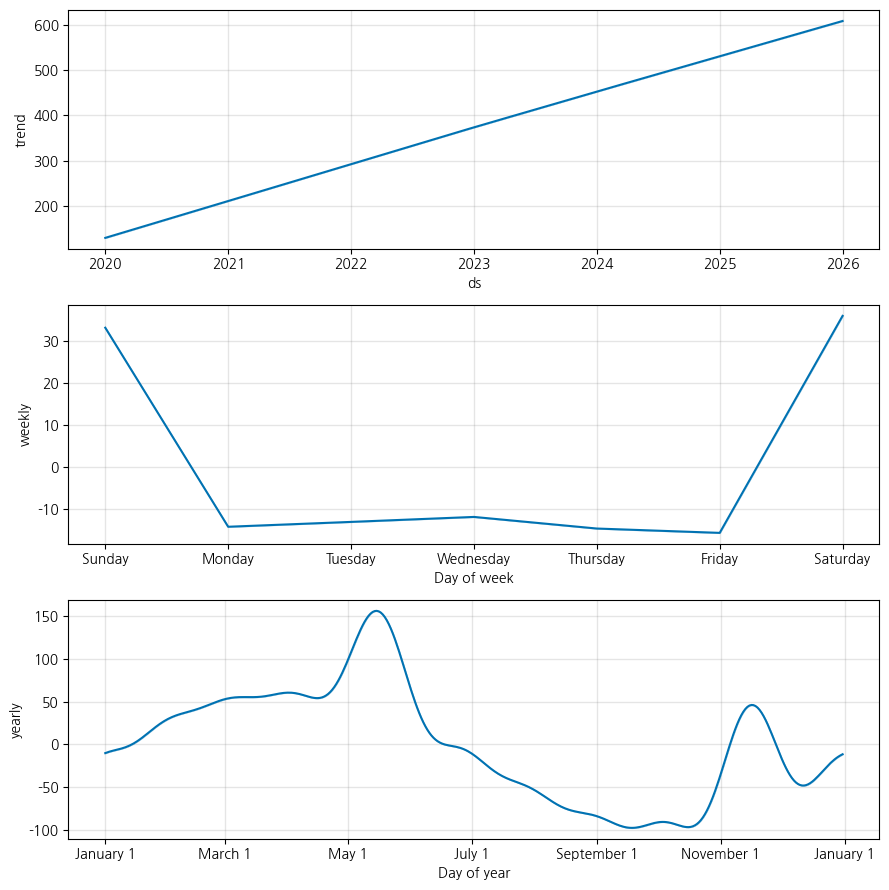

In [47]:
model.plot_components(forecast)
plt.show()

#### - 휴일 데이터 처리 = 중요!

In [67]:
# ds => datetime 처리 해주기
holidays = pd.read_csv('../data/holidays.csv', index_col= 0, parse_dates = ['ds'])

In [55]:
# 컬럼이름 : ds, lower_window, upper_window => prophet 실행하기 위해
holidays.head()

,holiday,ds,lower_window,upper_window
0,new_year,2020-01-01,0,1
1,promotion_may,2021-05-15,0,1
2,promotion_nov,2022-11-20,0,1
3,black_friday,2023-11-24,0,1


In [56]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   holiday       4 non-null      object        
 1   ds            4 non-null      datetime64[ns]
 2   lower_window  4 non-null      int64         
 3   upper_window  4 non-null      int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 160.0+ bytes


In [57]:
model = Prophet(holidays = holidays)

In [59]:
model.fit(df)

10:40:03 - cmdstanpy - INFO - Chain [1] start processing
10:40:03 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = model.make_future_dataframe(periods= 365, freq='D')

In [61]:
future

,ds
0,2020-01-01
1,2020-01-02
2,2020-01-03
3,2020-01-04
4,2020-01-05
...,...
2187,2025-12-27
2188,2025-12-28
2189,2025-12-29
2190,2025-12-30


In [63]:
forecast = model.predict(future)

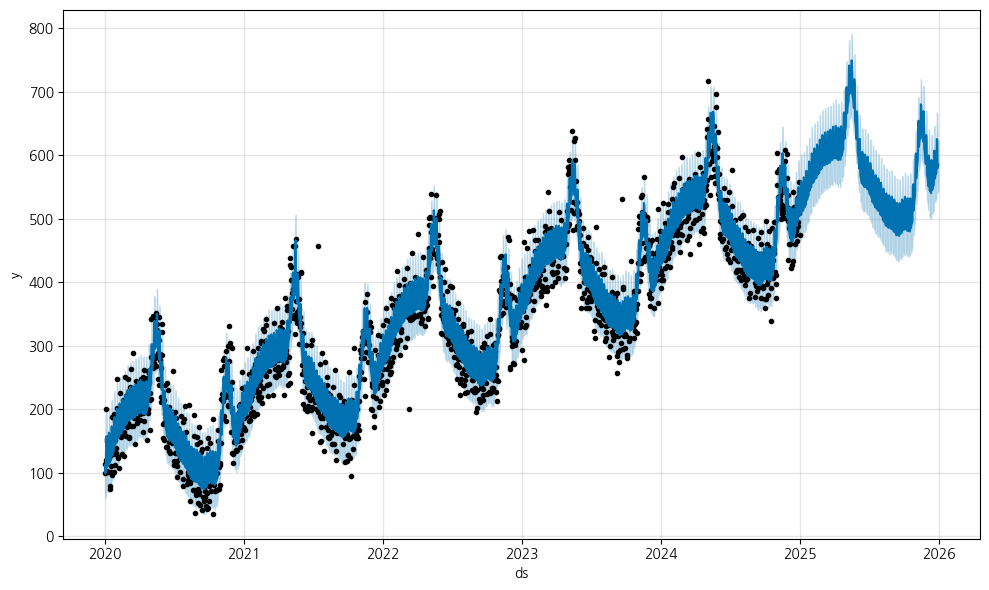

In [64]:
model.plot(forecast)
plt.show()

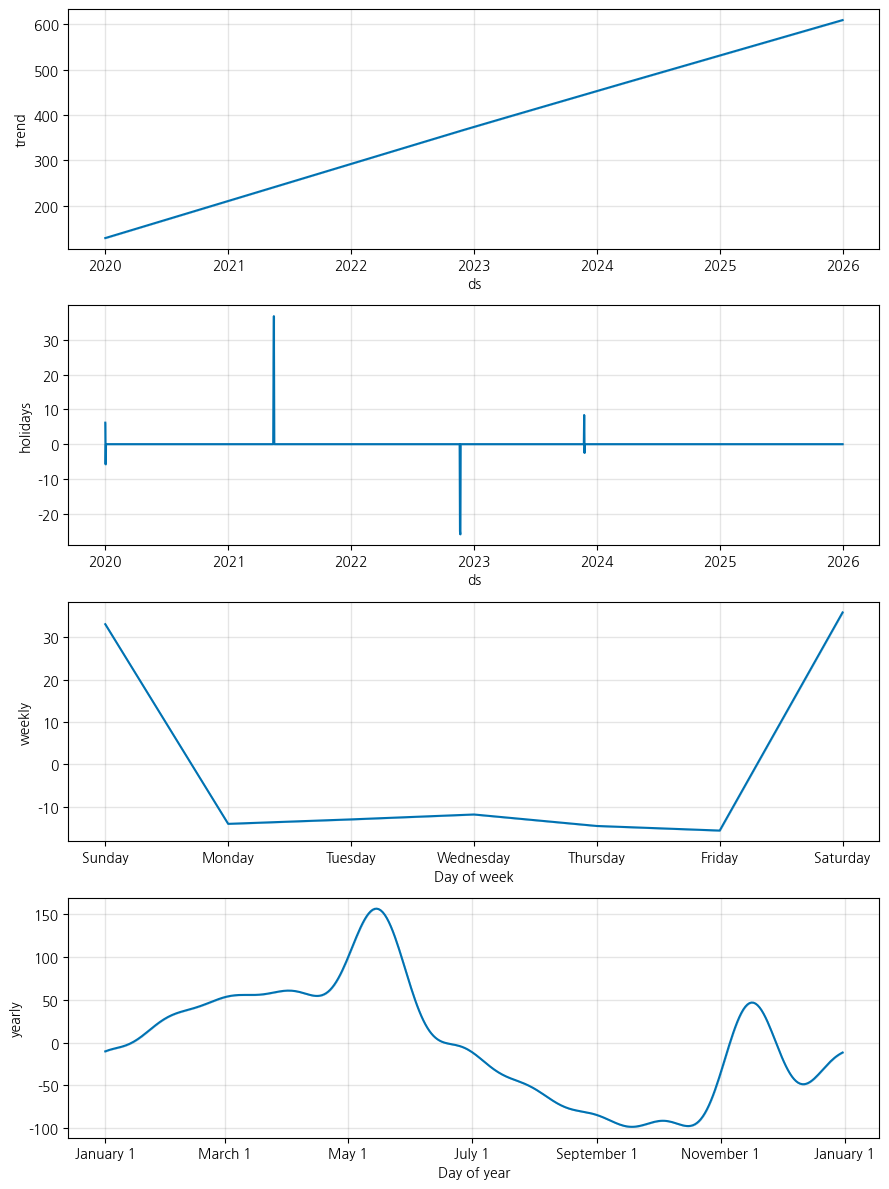

In [65]:
model.plot_components(forecast)
plt.show()